In [109]:
import os
import numpy as np
from scipy.io import loadmat
import pandas as pd
import matplotlib.pyplot as plt
import os

In [110]:
DATA_DIR = r"C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\Training_data"
OUT_DIR  = r"C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data"

In [111]:
FS = 125
WIN_SEC = 8
STEP_SEC = 2
WIN_LEN = WIN_SEC * FS     # 1000 samples
STEP_LEN = STEP_SEC * FS   # 250 samples

In [112]:
PARTICIPANT_IDS = [f"{i:02d}" for i in range(1, 13)]  # 01 - 12

In [113]:
def load_sig(path):
    data = loadmat(path, struct_as_record=False, squeeze_me=True)
    return data["sig"]  # shape (6, n_samples)


def load_bpm(path):
    data = loadmat(path, struct_as_record=False, squeeze_me=True)
    keys = [k for k in data.keys() if not k.startswith("__")]
    label_key = keys[0] if keys else "BPMtrace"
    return np.asarray(data[label_key]).ravel()


def build_segments(sig, bpm0, participant_id):
    n_rows, n_samples = sig.shape
    if n_rows < 5:
        raise ValueError(f"[{participant_id}] Expected at least 5 rows in sig, got {n_rows}")

    ppg1_row, ppg2_row = sig[1], sig[2]
    acc1_row, acc2_row, acc3_row = sig[3], sig[4], sig[5]

    n_labels = len(bpm0)
    max_possible = (n_samples - WIN_LEN) // STEP_LEN + 1

    if n_labels != max_possible:
        print(f"[{participant_id}] NOTE: BPM0 has {n_labels} windows, "
              f"signal length supports {max_possible} windows. "
              f"Using {min(n_labels, max_possible)} segments.")

    n_segments = min(n_labels, max_possible)

    segment_id = np.arange(n_segments, dtype=np.int32)
    ppg1 = np.zeros((n_segments, WIN_LEN), dtype=np.float64)
    ppg2 = np.zeros((n_segments, WIN_LEN), dtype=np.float64)
    acc1 = np.zeros((n_segments, WIN_LEN), dtype=np.float64)
    acc2 = np.zeros((n_segments, WIN_LEN), dtype=np.float64)
    acc3 = np.zeros((n_segments, WIN_LEN), dtype=np.float64)
    heart_rate = np.zeros(n_segments, dtype=np.float64)

    for i in range(n_segments):
        start = i * STEP_LEN
        end = start + WIN_LEN

        ppg1[i] = ppg1_row[start:end]
        ppg2[i] = ppg2_row[start:end]
        acc1[i] = acc1_row[start:end]
        acc2[i] = acc2_row[start:end]
        acc3[i] = acc3_row[start:end]
        heart_rate[i] = bpm0[i]

    return {
        "participant_id": participant_id,
        "segment_id": segment_id,
        "ppg1": ppg1,
        "ppg2": ppg2,
        "acc1": acc1,
        "acc2": acc2,
        "acc3": acc3,
        "heart_rate": heart_rate,
        "fs": FS,
        "win_sec": WIN_SEC,
        "step_sec": STEP_SEC,
    }


def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    for pid in PARTICIPANT_IDS:
        sig_path = os.path.join(DATA_DIR, f"DATA_{pid}_TYPE02.mat")
        label_path = os.path.join(DATA_DIR, f"DATA_{pid}_TYPE02_BPMtrace.mat")

        if not (os.path.exists(sig_path) and os.path.exists(label_path)):
            print(f"[{pid}] SKIPPED — missing file(s):")
            if not os.path.exists(sig_path):
                print(f"    missing: {sig_path}")
            if not os.path.exists(label_path):
                print(f"    missing: {label_path}")
            continue

        sig = load_sig(sig_path)
        bpm0 = load_bpm(label_path)

        segments = build_segments(sig, bpm0, pid)

        out_path = os.path.join(OUT_DIR, f"participant_{pid}.npy")
        np.save(out_path, segments, allow_pickle=True)

        print(f"[{pid}] Saved {segments['segment_id'].shape[0]} segments -> {out_path}")

    print("\nDone.")    


In [114]:
if __name__ == "__main__":
    main()

[01] Saved 148 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_01.npy
[02] Saved 148 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_02.npy
[03] Saved 140 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_03.npy
[04] Saved 146 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_04.npy
[05] Saved 146 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_05.npy
[06] Saved 150 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_06.npy
[07] Saved 143 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\participant_07.npy
[08] Saved 160 segments -> C:\Users\thami\Desktop\my lec sem 7\BioSignals\Project\competition_data\npy_data\par

In [115]:
for participant in range(1, 13):
    print(f"Loading participant {participant:02d} data...")
    data = np.load(
        f"competition_data/npy_data/participant_{participant:02d}.npy",
        allow_pickle=True,
    ).item()

   
    print(f"  ppg1 shape       : {data['ppg1'].shape}")
    print(f"  heart_rate shape : {data['heart_rate'].shape}\n")

Loading participant 01 data...
  ppg1 shape       : (148, 1000)
  heart_rate shape : (148,)

Loading participant 02 data...
  ppg1 shape       : (148, 1000)
  heart_rate shape : (148,)

Loading participant 03 data...
  ppg1 shape       : (140, 1000)
  heart_rate shape : (140,)

Loading participant 04 data...
  ppg1 shape       : (146, 1000)
  heart_rate shape : (146,)

Loading participant 05 data...
  ppg1 shape       : (146, 1000)
  heart_rate shape : (146,)

Loading participant 06 data...
  ppg1 shape       : (150, 1000)
  heart_rate shape : (150,)

Loading participant 07 data...
  ppg1 shape       : (143, 1000)
  heart_rate shape : (143,)

Loading participant 08 data...
  ppg1 shape       : (160, 1000)
  heart_rate shape : (160,)

Loading participant 09 data...
  ppg1 shape       : (149, 1000)
  heart_rate shape : (149,)

Loading participant 10 data...
  ppg1 shape       : (149, 1000)
  heart_rate shape : (149,)

Loading participant 11 data...
  ppg1 shape       : (143, 1000)
  hear

In [116]:
NPY_PATH = r"competition_data/npy_data/participant_01.npy"
data = np.load(NPY_PATH, allow_pickle=True).item()
N_ROWS = 5

In [117]:
df = pd.DataFrame(
    {
        "segment_id": data["segment_id"][:N_ROWS],
        "ppg1": [row for row in data["ppg1"][:N_ROWS]],  # Array of 1000 samples
        "ppg2": [row for row in data["ppg2"][:N_ROWS]],
        "acc1": [row for row in data["acc1"][:N_ROWS]],
        "acc2": [row for row in data["acc2"][:N_ROWS]],
        "acc3": [row for row in data["acc3"][:N_ROWS]],
        "bpm": data["heart_rate"][:N_ROWS],
    }
)


pd.set_option("display.max_colwidth", None)

In [118]:
display(df)  

,segment_id,ppg1,ppg2,acc1,acc2,acc3,bpm
0,0,"[-23.0, -24.0, -26.5, -27.0, -30.0, -30.0, -28.5, -28.0, -29.0, -29.0, -27.0, -24.5, -23.5, -23.0, -21.5, -19.0, -17.5, -17.5, -15.0, -16.0, -14.0, -13.5, -14.0, -13.0, -14.0, -14.5, -15.5, -16.5, -18.0, -20.5, -19.5, -20.0, -23.5, -24.0, -26.0, -25.5, -26.0, -28.0, -29.5, -31.0, -30.5, -31.5, -34.0, -36.0, -37.5, -38.0, -39.0, -41.0, -41.0, -42.0, -41.5, -41.0, -41.5, -40.5, -40.0, -36.5, -37.0, -34.5, -33.5, -31.5, -28.5, -27.5, -27.0, -25.5, -25.0, -22.5, -21.5, -20.5, -17.0, -15.0, -11.0, -8.5, -5.0, 0.0, 5.5, 11.5, 18.5, 24.5, 31.0, 38.5, 44.0, 50.5, 55.5, 58.0, 61.0, 62.5, 65.5, 65.0, 63.5, 63.0, 63.0, 62.0, 59.0, 57.5, 54.5, 54.0, 51.5, 47.5, 45.0, 41.0, ...]","[4.0, 6.0, 3.0, 3.5, 0.0, 2.0, 3.0, 3.5, 3.0, 3.0, 5.5, 6.5, 7.5, 7.5, 7.0, 7.0, 8.5, 7.5, 7.0, 6.5, 6.5, 6.5, 5.5, 7.5, 6.0, 7.5, 7.0, 6.5, 5.5, 2.5, 4.0, 3.0, 1.5, -0.5, -2.5, -3.0, -4.0, -5.5, -6.5, -8.5, -8.0, -9.5, -12.0, -12.5, -14.0, -14.5, -14.5, -17.0, -17.0, -17.5, -17.0, -18.5, -20.5, -21.5, -24.0, -23.0, -23.5, -23.5, -22.5, -23.5, -22.5, -21.0, -20.0, -19.0, -18.5, -16.5, -15.5, -15.0, -12.0, -11.5, -8.0, -5.0, -2.5, 1.5, 7.0, 11.5, 18.0, 24.0, 30.5, 35.5, 42.0, 47.0, 51.5, 54.0, 55.5, 59.0, 61.5, 60.5, 58.5, 56.5, 55.0, 51.5, 47.0, 44.5, 38.5, 36.5, 32.0, 25.5, 21.5, 14.5, ...]","[-0.0702, -0.0702, -0.054599999999999996, -0.046799999999999994, -0.046799999999999994, -0.046799999999999994, -0.046799999999999994, -0.0312, -0.0312, -0.039, -0.046799999999999994, -0.046799999999999994, -0.039, -0.046799999999999994, -0.046799999999999994, -0.023399999999999997, -0.0156, -0.0078, -0.0078, 0.0, -0.0078, 0.0, 0.0, 0.0078, 0.0156, 0.0156, 0.023399999999999997, 0.0312, 0.039, 0.054599999999999996, 0.046799999999999994, 0.054599999999999996, 0.0624, 0.0624, 0.078, 0.0702, 0.0702, 0.0702, 0.0624, 0.0624, 0.039, 0.0312, 0.023399999999999997, 0.0156, 0.0, -0.0078, -0.0156, -0.023399999999999997, -0.0312, -0.0312, -0.039, -0.046799999999999994, -0.0624, -0.078, -0.0624, -0.046799999999999994, -0.0312, -0.0156, -0.039, -0.039, -0.023399999999999997, -0.0156, -0.023399999999999997, 0.0, 0.0, 0.0078, 0.0078, 0.0078, 0.0, -0.0078, -0.0156, -0.039, -0.054599999999999996, -0.09359999999999999, -0.10919999999999999, -0.1326, -0.1482, -0.1482, -0.1482, -0.1638, -0.156, -0.1404, -0.1404, -0.11699999999999999, -0.10919999999999999, -0.10139999999999999, -0.0858, -0.078, -0.078, -0.078, -0.0702, -0.078, -0.078, -0.0858, -0.078, -0.0858, -0.078, -0.0858, -0.0702, -0.0702, ...]","[0.3432, 0.3588, 0.3666, 0.3666, 0.37439999999999996, 0.38999999999999996, 0.40559999999999996, 0.4134, 0.42119999999999996, 0.42119999999999996, 0.4134, 0.40559999999999996, 0.3978, 0.3978, 0.38999999999999996, 0.3978, 0.38999999999999996, 0.40559999999999996, 0.4134, 0.40559999999999996, 0.3978, 0.38999999999999996, 0.3822, 0.3822, 0.3822, 0.3822, 0.37439999999999996, 0.37439999999999996, 0.37439999999999996, 0.3666, 0.3666, 0.3588, 0.3588, 0.3432, 0.3432, 0.3354, 0.3276, 0.3198, 0.3198, 0.3354, 0.351, 0.37439999999999996, 0.40559999999999996, 0.429, 0.4446, 0.4758, 0.4836, 0.4758, 0.4758, 0.46799999999999997, 0.4602, 0.43679999999999997, 0.4134, 0.38999999999999996, 0.3588, 0.3432, 0.3276, 0.3354, 0.3432, 0.3666, 0.3822, 0.3978, 0.4134, 0.429, 0.429, 0.43679999999999997, 0.43679999999999997, 0.45239999999999997, 0.4602, 0.4602, 0.4836, 0.4836, 0.4758, 0.4836, 0.4836, 0.4758, 0.46799999999999997, 0.46799999999999997, 0.4758, 0.4758, 0.4914, 0.4992, 0.5147999999999999, 0.5304, 0.5459999999999999, 0.5616, 0.585, 0.6006, 0.624, 0.6162, 0.6317999999999999, 0.6317999999999999, 0.624, 0.6317999999999999, 0.6162, 0.6083999999999999, 0.6083999999999999, 0.6006, 0.6006, 0.585, ...]","[0.9593999999999999, 0.9438, 0.9359999999999999, 0.9359999999999999, 0.9126, 0.9126, 0.9281999999999999, 0.9359999999999999, 0.9281999999999999, 0.9204, 0.9126, 0.9126, 0.8892, 0.8814, 0.8735999999999999, 0.8735999999999999, 0.8658, 0.858, 0.8658, 0.8502, 0.8423999999999999, 0.81119

In [119]:
file_size_mb = os.path.getsize(NPY_PATH) / (1024 * 1024)
raw_npy = np.load(NPY_PATH, allow_pickle=True)
data_dict = raw_npy.item()

In [120]:
print("=" * 75)
print(f" FILE LAYOUT REPORT: {os.path.basename(NPY_PATH)}")
print("=" * 75)
print(f" File Size on Disk   : {file_size_mb:.2f} MB")
print(f" Outer NumPy Wrapper : {type(raw_npy)} | shape={raw_npy.shape} | dtype={raw_npy.dtype}")
print(f" Inner Container     : {type(data_dict)} with {len(data_dict)} top-level keys")
print("=" * 75)


print(f"{'KEY NAME':<16} | {'DATA TYPE':<18} | {'SHAPE / VALUE':<18} | {'MEMORY':<10}")
print("-" * 75)

for key, value in data_dict.items():
    if isinstance(value, np.ndarray):
        type_str = f"ndarray ({value.dtype})"
        shape_str = str(value.shape)
        mem_str = f"{value.nbytes / 1024:.1f} KB"
    else:
        type_str = f"Python {type(value).__name__}"
        shape_str = str(value)
        mem_str = "-"
    
    print(f"{key:<16} | {type_str:<18} | {shape_str:<18} | {mem_str:<10}")

print("=" * 75)


n_seg = data_dict['ppg1'].shape[0]
win_len = data_dict['ppg1'].shape[1]

print("\nSEGMENT-LEVEL MATRIX ARRANGEMENT:")
print(f" Each segment [i] (from 0 to {n_seg-1}) represents an 8-second window ({win_len} samples @ {data_dict['fs']} Hz):\n")
print(f"  Segment [i] --->  ppg1[i]       : shape ({win_len},)  [1000 time-series samples]")
print(f"                    ppg2[i]       : shape ({win_len},)  [1000 time-series samples]")
print(f"                    acc1[i]       : shape ({win_len},)  [1000 time-series samples]")
print(f"                    acc2[i]       : shape ({win_len},)  [1000 time-series samples]")
print(f"                    acc3[i]       : shape ({win_len},)  [1000 time-series samples]")
print(f"                    heart_rate[i] : float scalar     [Ground truth BPM for window i]")

 FILE LAYOUT REPORT: participant_01.npy
 File Size on Disk   : 5.65 MB
 Outer NumPy Wrapper : <class 'numpy.ndarray'> | shape=() | dtype=object
 Inner Container     : <class 'dict'> with 11 top-level keys
KEY NAME         | DATA TYPE          | SHAPE / VALUE      | MEMORY    
---------------------------------------------------------------------------
participant_id   | Python str         | 01                 | -         
segment_id       | ndarray (int32)    | (148,)             | 0.6 KB    
ppg1             | ndarray (float64)  | (148, 1000)        | 1156.2 KB 
ppg2             | ndarray (float64)  | (148, 1000)        | 1156.2 KB 
acc1             | ndarray (float64)  | (148, 1000)        | 1156.2 KB 
acc2             | ndarray (float64)  | (148, 1000)        | 1156.2 KB 
acc3             | ndarray (float64)  | (148, 1000)        | 1156.2 KB 
heart_rate       | ndarray (float64)  | (148,)             | 1.2 KB    
fs               | Python int         | 125                | -         

In [121]:
SEG_IDX = 0 

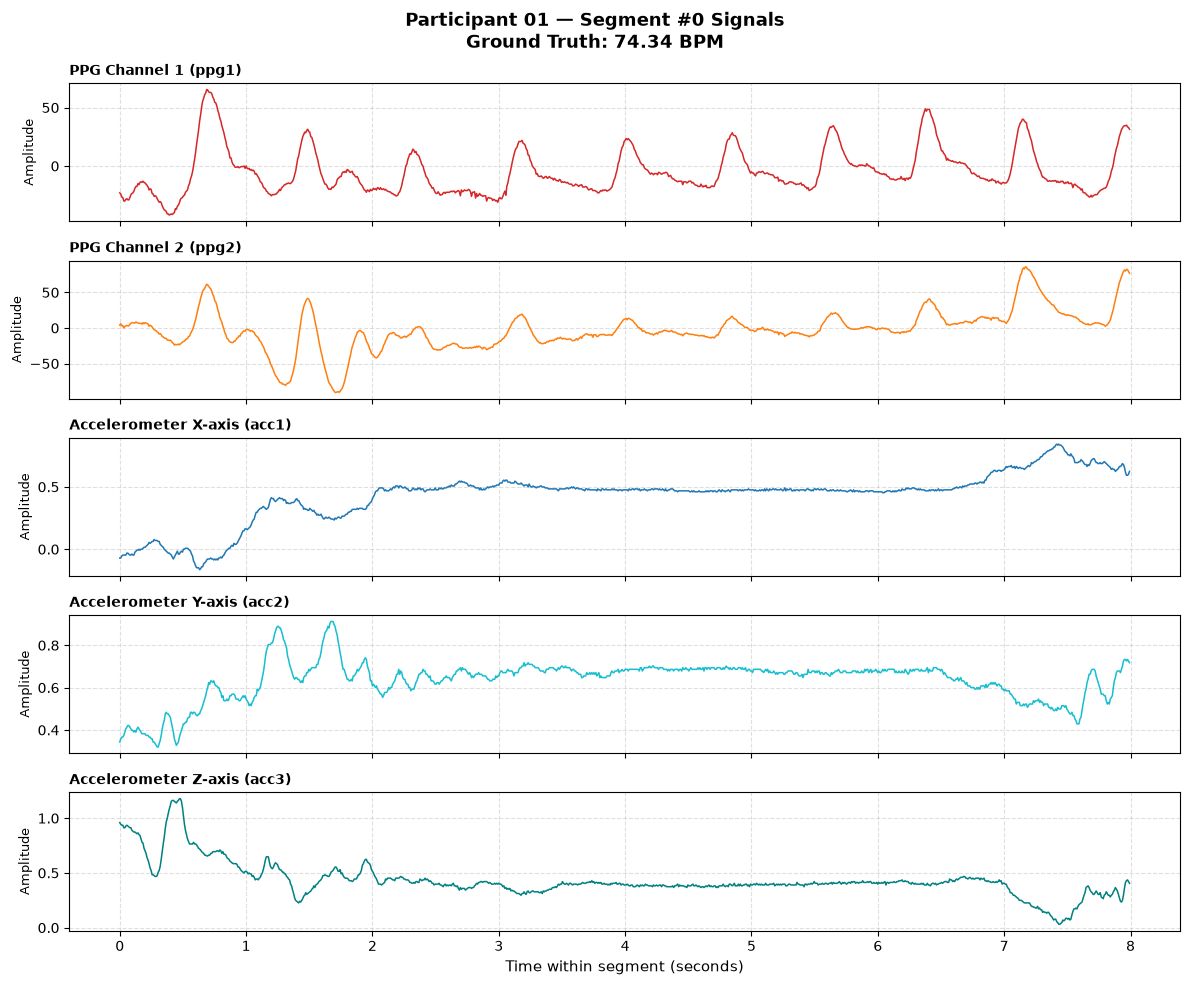

In [122]:
fs = data.get("fs", 125)
win_len = data_dict["ppg1"].shape[1]
time_axis = np.arange(win_len) / fs  


channels = [
    ("PPG Channel 1 (ppg1)", data["ppg1"][SEG_IDX], "tab:red"),
    ("PPG Channel 2 (ppg2)", data["ppg2"][SEG_IDX], "tab:orange"),
    ("Accelerometer X-axis (acc1)", data["acc1"][SEG_IDX], "tab:blue"),
    ("Accelerometer Y-axis (acc2)", data["acc2"][SEG_IDX], "tab:cyan"),
    ("Accelerometer Z-axis (acc3)", data["acc3"][SEG_IDX], "teal"), 
]


fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

pid = data.get("participant_id", "01")
bpm_val = data["heart_rate"][SEG_IDX]

fig.suptitle(
    f"Participant {pid} — Segment #{SEG_IDX} Signals\nGround Truth: {bpm_val:.2f} BPM",
    fontsize=13,
    fontweight="bold",
)

for ax, (name, sig_data, color) in zip(axes, channels):
    ax.plot(time_axis, sig_data, color=color, linewidth=1.1)
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.set_title(name, fontsize=10, loc="left", fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Time within segment (seconds)", fontsize=11)
plt.tight_layout()
plt.show()